In [1]:
from src import *

In [2]:
def log_target0(x):
    return -0.5 * x**2
def log_target1(x, D=4):
    return -0.5 * (x - D)**2
def log_target_path(x, path):
    return (1-path) * log_target0(x) + path * log_target1(x)
def grad_log_target_path(x):
    return log_target1(x, D=4) - log_target0(x)

- Initialisation of the hyperparameters 

In [3]:
L = 20  # 0, 0.1, ..., 1.0
nrep = 100
sigmaq = 1
lag = 1
lambda_grid = np.arange(0, L + 1) / L # uniform grid of lambda values in [0, 1]

### Tuning of the parameters $k_\lambda$ and $m_\lambda$ over a uniform grid of size $L$

mk tunning: 100%|██████████| 21/21 [00:00<00:00, 46.40it/s]


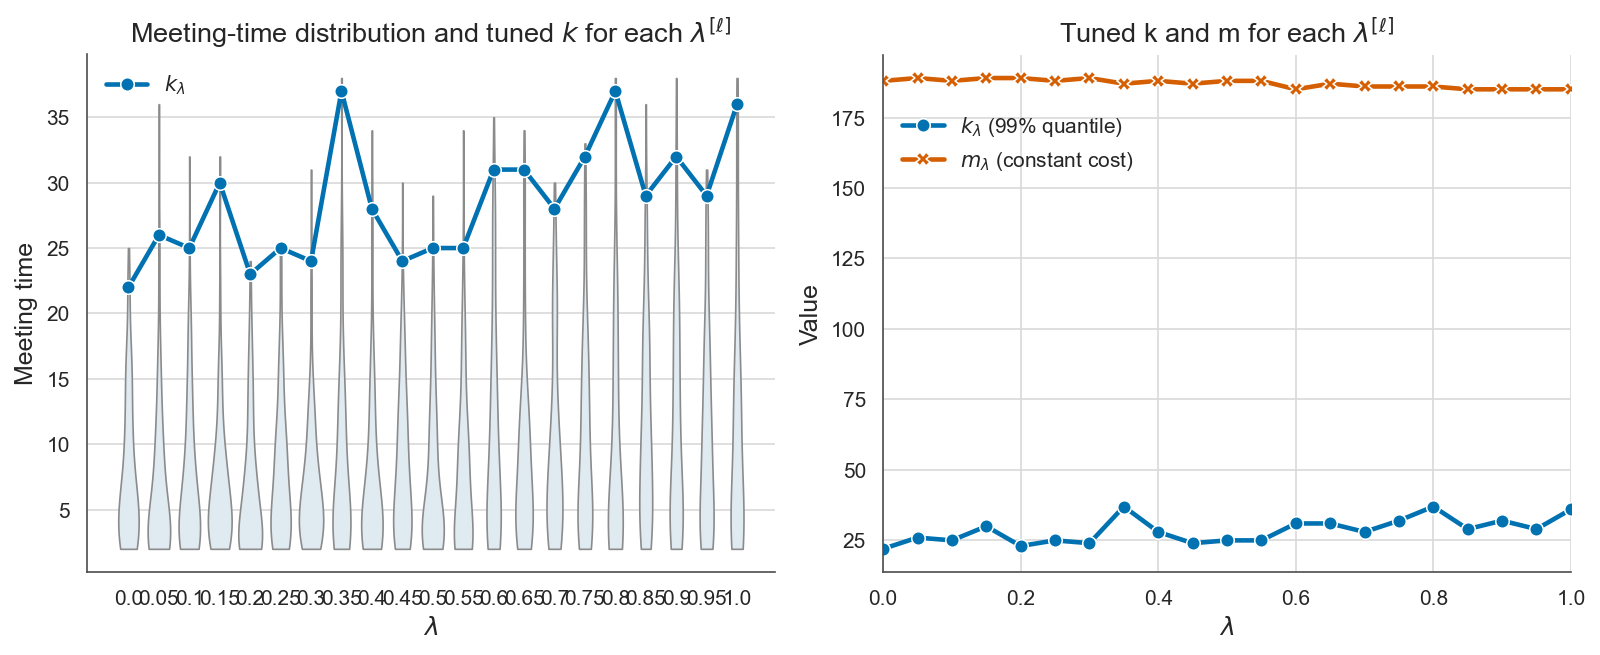

In [4]:
km_grid = tune_km_grid(lambda_grid, lag = lag, sigmaq = sigmaq, log_target_path = log_target_path, nrep = nrep)
plot_km_grid(lambda_grid, lag = lag, sigmaq = sigmaq, log_target_path = log_target_path, nrep = nrep)

### Variance of the UMCMC estimator and the second moment over the grid 
- $\hat{E}(\lambda)$ is the UMCMC of the expectation $\mathbb{E}_{\pi_\lambda}[\nabla_\lambda \log \pi_\lambda]$

Final estimation: 100%|██████████| 21/21 [00:05<00:00,  3.76it/s]


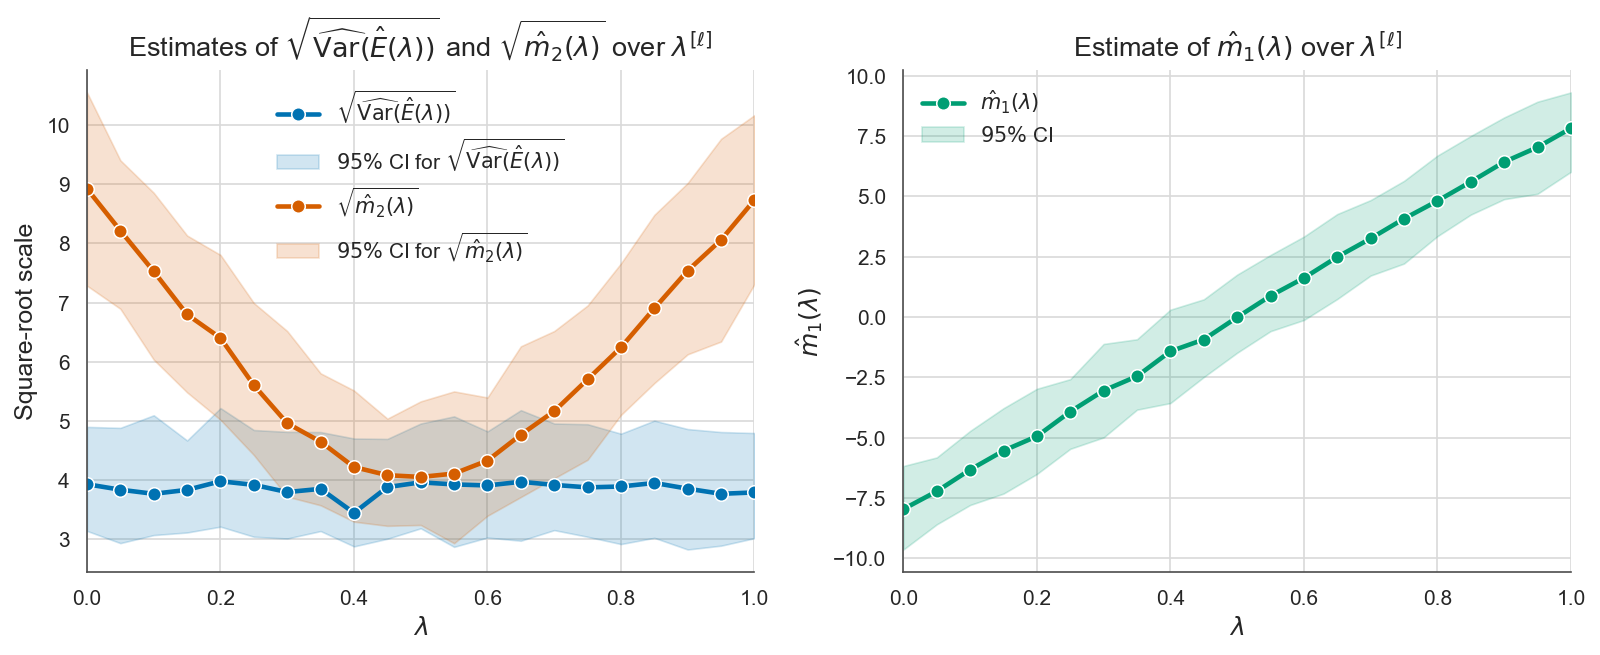

In [5]:
k_grid, m_grid = km_grid["k_grid"], km_grid["m_grid"]
plot_estimate_mom(lambda_grid, k_grid, m_grid, nrep, sigmaq, lag, log_target_path, grad_log_target_path)

### Comparaison of IS and Startified based estimator

- Stratified estimator

In [6]:
L = 20

- IS estimator

In [7]:
res = estimate_mom(lambda_grid, k_grid, m_grid, nrep, sigmaq, lag, log_target_path, grad_log_target_path)
sqrt_m2 = np.sqrt(res["m2"])

Final estimation: 100%|██████████| 21/21 [00:05<00:00,  3.66it/s]


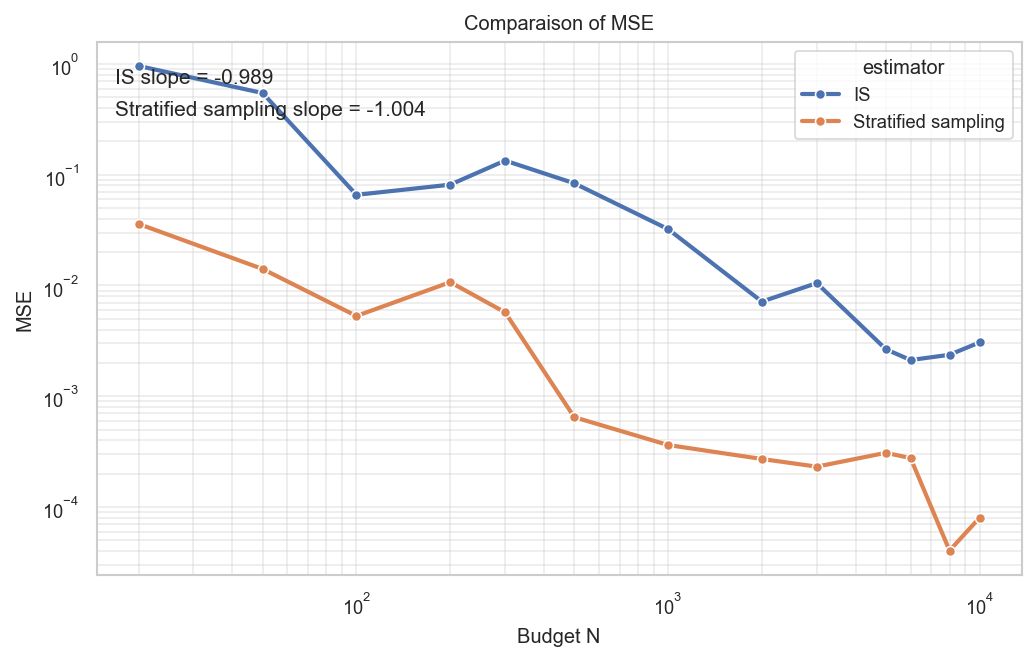

Estimated log-log slopes:
- IS: -0.989
- Stratified sampling: -1.004


In [ ]:
M_grid = np.array([20, 50, 100, 200, 300, 500, 1000, 2000, 3000, 5000, 6000, 8000, 10000]) #, 220, 250, 270, 290, 320, 350, 380, 500, 1000]) # 500, 1000, 2000, 3000, 5000
estimator = lambda lam: uestimator_given_lambda(lam, lambda_grid, k_grid, m_grid, sigmaq, lag, log_target_path, grad_log_target_path)

df_results = compare_mse_budget_grid_plot(
    L=L,
    M_grid=M_grid,
    estimator=estimator,
    sqrt_m2=sqrt_m2,
    true_value=0,
    nrep=10,
    n_samples_per_bin=10
)




In [ ]:

sns.set_theme(style="whitegrid", context="paper")

plt.figure(figsize=(7, 4.5), dpi=150)

sns.lineplot(
    data=df_results,
    x="M",
    y="mse",
    hue="estimator",
    marker="o",
    linewidth=2
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Budget N")
plt.ylabel("MSE")
plt.title("Comparaison of MSE")
plt.grid(True, which="both", alpha=0.4)
plt.legend(fontsize = 20)

slopes = {}
for estimator_name in df_results["estimator"].unique():
    df_est = df_results[df_results["estimator"] == estimator_name]
    logM = np.log(df_est["M"].astype(float).values)
    logmse = np.log(df_est["mse"].astype(float).values)
    slope, intercept = np.polyfit(logM, logmse, 1)
    slopes[estimator_name] = slope

text_y = 0.95
for estimator_name, slope in slopes.items():
    plt.text(
        0.02,
        text_y,
        f"{estimator_name} slope = {slope:.3f}",
        transform=plt.gca().transAxes,
        fontsize=20,
        verticalalignment="top"
    )
    text_y -= 0.06

plt.tight_layout()
plt.show()

print("Estimated log-log slopes:")
for estimator_name, slope in slopes.items():
    print(f"- {estimator_name}: {slope:.3f}")

- Box Plots 

In [11]:
M = 50
estimator = lambda lam: uestimator_given_lambda(lam, lambda_grid, k_grid, m_grid, sigmaq, lag, log_target_path, grad_log_target_path)

budget = build_budget(
            L=L,
            M=M,
            estimator=estimator,
            n_samples_per_bin=10
        )
estimators = [lambda : q_unbiased_estimator(L, M, estimator, sqrt_m2), lambda : optimal_startified_estimator(L, estimator, budget)]

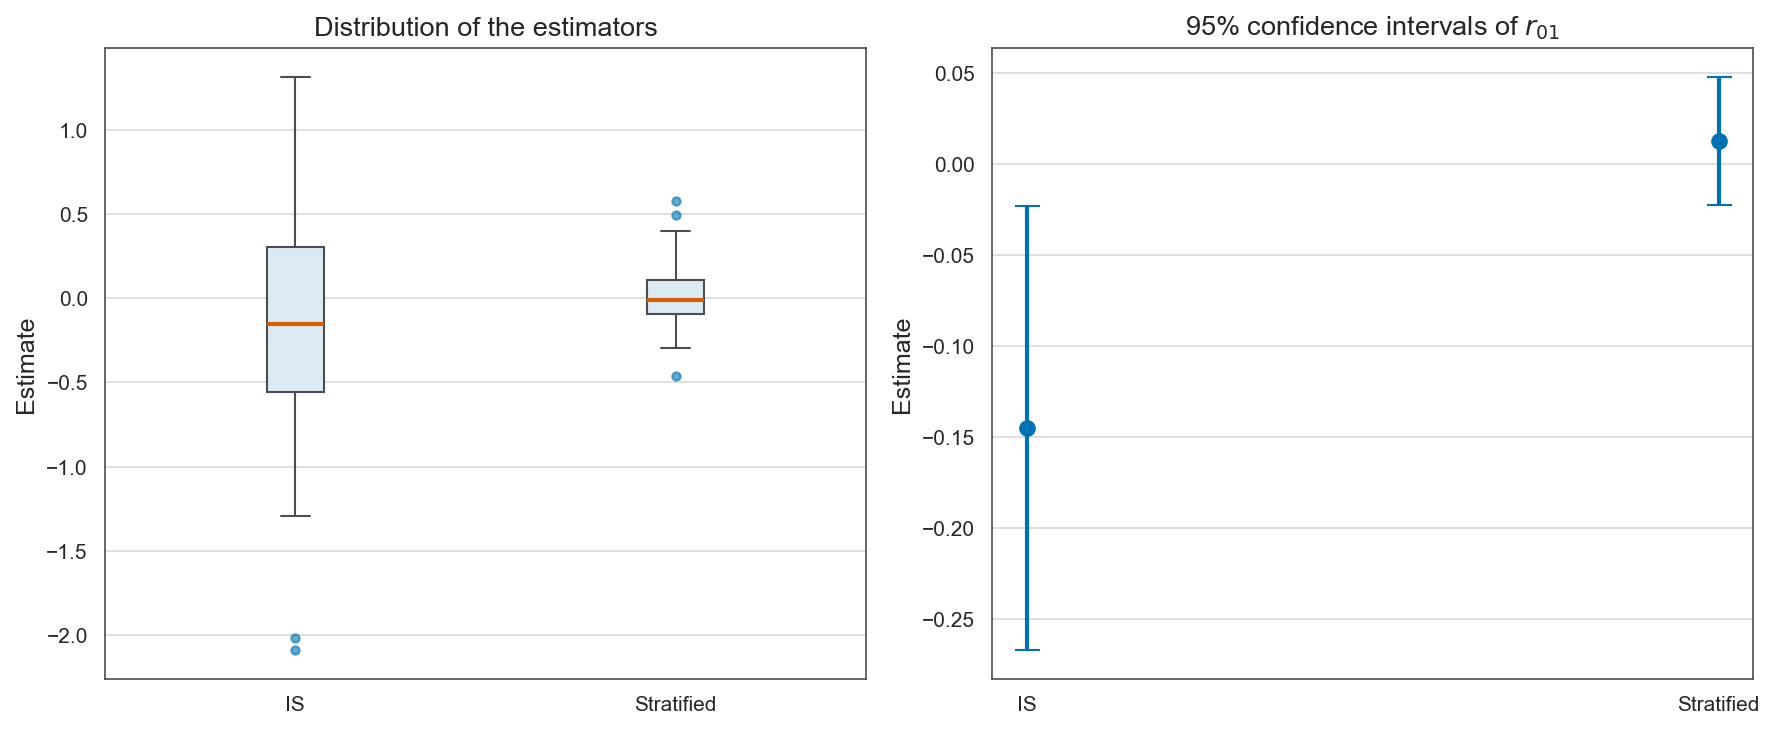

IS: CI = [-0.267156, -0.022774], length = 0.244382
Stratified: CI = [-0.022204, 0.048228], length = 0.070432


{'samples': [array([ 4.90163308e-01,  2.99305547e-01,  3.48143175e-01, -2.08937780e+00,
          7.18930446e-01, -6.84260693e-02, -1.70686543e-01,  5.34583210e-01,
         -1.97341387e-01, -6.00380276e-01, -9.25146365e-01,  2.68428285e-01,
          6.76987070e-01,  5.97244864e-01, -1.39334639e-01, -6.03928050e-01,
          1.22783066e-02, -3.31341575e-01, -1.05778662e-01, -6.38564893e-01,
          9.79242463e-02, -3.03925963e-01, -3.68284955e-01, -8.94781479e-01,
         -7.35733694e-01, -6.32003938e-01, -4.34884711e-04,  9.45793827e-02,
         -5.42376621e-01, -9.96196272e-01, -8.38501198e-01, -3.98905116e-01,
          8.57136999e-01, -6.08845627e-01, -3.98902083e-02,  1.22534069e+00,
          5.93045201e-01, -2.81127619e-01, -3.11663675e-01,  3.76613636e-01,
         -1.07742924e+00, -1.21324493e+00, -5.78269660e-01,  5.87441927e-01,
          9.31025974e-03, -2.62848823e-01, -4.73368642e-02, -1.29487286e+00,
         -5.52061255e-01, -7.33887385e-01, -3.33457598e-01, -5.07

In [12]:
plot_estimators_box_CI(
    estimators,
    labels = ['IS', 'Stratified'],
    nrep=100,
    ci_level=0.95,
    figsize=(12, 5),
)